# SPARC-4 products
***

This notebook shows an example for viewing and accessing the SPARC4 data products.

* Eder Martioli, LNA 18 Apr 2024
* Fernando Falkenberg INPE 09 Oct 2025

In [2]:
from astropy.io import fits, ascii
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import sparc4.product_plots as s4plt
import sparc4.pipeline_lib as s4pipelib

### Set paths to example files 
Below we set the paths to the files, which are sparc4-pipeline products.

In [4]:
path = '/media/fernando/KINGSTON/Doutorado/2025/reduced/'
date = '20250701'
object = 'V2400_Oph'
channel = '2'

In [5]:
db_example = f'{path}{date}/sparc4acs{channel}/{date}_sparc4acs{channel}_db.csv'
# Esse arquivo é uma tabela que contém informações de todas as imagens daquela noite, naquele canal, por exemplo, diretório, tempo de exposição, posição da lâmina, etc.

phot_lightcurve_example = f'{path}{date}/sparc4acs{channel}/{date}_s4c{channel}_{object}_POLAR_L4_S+N_lc.fits'
# Esse arquivo contém várias tabelas dentro dele, uma pra cada abertura em que os dados do objeto foram processados. Dentro de cada tabela, estão informações de cada uma das fontes detectadas pelo pipeline, para cada imagem daquele objeto, por exemplo, RA, Dec, magnitude (com seu erro), fwhm, etc.

polar_stack_example = f'{path}{date}/sparc4acs{channel}/{date}_s4c{channel}_Gain2_1.0_Conventional_2_{object}_POLAR_L4_stack.fits'
# Esse arquivo contém várias tabelas dentro dele, duas para cada abertura em que os dados do objeto foram processados (sendo uma para o feixe ordinário e a outra para o feixe extraordinário). Cada tabela contém uma linha para cada fonte identificada pelo pipeline. Para cada linha, existem informações como RA, Dec, magnitude (com seu erro), fwhm, etc. É uma versão do arquivo logo acima, só que para apenas uma imagem stack.

polar_example = f'{path}{date}/sparc4acs{channel}/{date}_s4c{channel}_Gain2_1.0_Conventional_2_{object}_POLAR_L4_polar.fits'
# Esse arquivo contém várias tabelas, uma pra cada abertura em que os dados do objeto foram processados. Dentro de cada tabela existe uma linha para cada fonte detectada pelo pipeline. Em cada linha estão os resultados da polarimetria para aquela fonte, por exemplo, x1, y1, x2, y2, mag, emag, Q, U, V, P, theta, fwhm, zero, ezero, k, chi2, rms... Além disso, também estão as contagens para cada posição de lâmina, para cada fonte, para cada imagem, com seus erros. É nesse arquivo que estão os dados importantes.

polar_time_series_example = f'{path}{date}/sparc4acs{channel}/{date}_s4c{channel}_{object}_POLAR_L4_ts.fits'
# Esse arquivo contém uma tabela com os dados da série temporal polarimétrica das fontes detectadas pelo pipeline, por exemplo, RA, Dec, x1, y1, x2, y2, mag, emag, Q, U, V, P, theta, fwhm, zero, ezero, k, chi2, rms... O resultado aqui é para cada conjunto de uma medida polarimétrica.

# DB product example
***
In this simple example, we just read the database created by the `sparc4-pipeline` and print it as a pandas table. It's an easy way to quickly access the log of observations.

In [7]:
db = ascii.read(db_example)
pd.DataFrame(np.array(db))

,FILE,DATE-OBS,EXPTIME,RA,DEC,OBJECT,OBSTYPE,INSTMODE,CHANNEL,VBIN,...,VCLKAMP,CCDSERN,PREAMP,READRATE,EMMODE,EMGAIN,WPPOS,WPSEL,CALW,ASEL
0,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-01T21:53:20.327000,0.2,11:17:12.01,-38:00:51.70,HD98161,OBJECT,POLAR,2,1,...,Normal,9915,Gain 2,1.0,Conventional,2,1,L2,None,True
1,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-01T21:53:21.647063,0.2,11:17:12.01,-38:00:51.70,HD98161,OBJECT,POLAR,2,1,...,Normal,9915,Gain 2,1.0,Conventional,2,1,L2,None,True
2,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-01T21:53:22.967126,0.2,11:17:12.01,-38:00:51.70,HD98161,OBJECT,POLAR,2,1,...,Normal,9915,Gain 2,1.0,Conventional,2,1,L2,None,True
3,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-01T21:53:24.287189,0.2,11:17:12.01,-38:00:51.70,HD98161,OBJECT,POLAR,2,1,...,Normal,9915,Gain 2,1.0,Conventional,2,1,L2,None,True
4,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-01T21:53:27.114000,0.2,11:17:12.01,-38:00:51.70,HD98161,OBJECT,POLAR,2,1,...,Normal,9915,Gain 2,1.0,Conventional,2,2,L2,None,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
653,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-02T04:59:06.324000,40.0,22:17:55.38,-08:21:04.60,FO_Aqr,OBJECT,POLAR,2,1,...,Normal,9915,Gain 2,1.0,Conventional,2,8,L4,None,True
654,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-02T04:59:48.869000,40.0,22:17:55.38,-08:21:04.60,FO_Aqr,OBJECT,POLAR,2,1,...,Normal,9915,Gain 2,1.0,Conventional,2,9,L4,None,True
655,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-02T05:00:31.394000,40.0,22:17:55.38,-08:21:04.60,FO_Aqr,OBJECT,POLAR,2,1,...,Normal,9915,Gain 2,1.0,Conventional,2,10,L4,None,True
656,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-02T05:01:13.999000,40.0,22:17:55.38,-08:21:04.60,FO_Aqr,OBJECT,POLAR,2,1,...,Normal,9915,Gain 2,1.0,Conventional,2,11,L4,None,True


# POLAR products example
***
In this example we show how to work with the polarimetric products of SPARC4

We start by reading the science image FITS file and showing its information. 

In [10]:
hdul = fits.open(polar_stack_example)
hdul.info()

Filename: /media/fernando/KINGSTON/Doutorado/2025/reduced/20250701/sparc4acs2/20250701_s4c2_Gain2_1.0_Conventional_2_V2400_Oph_POLAR_L4_stack.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     157   (1024, 1024)   float64   
  1  CATALOG_POL_S_AP005    1 TableHDU        51   37R x 13C   [I11, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, I11, I11]   
  2  CATALOG_POL_N_AP005    1 TableHDU        51   37R x 13C   [I11, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, I11, I11]   
  3  CATALOG_POL_S_AP008    1 TableHDU        51   37R x 13C   [I11, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, I11, I11]   
  4  CATALOG_POL_N_AP008    1 TableHDU        51   37R x 13C   [I11, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, I11, I11]   
  5  CATALOG_POL_S_AP010    1 TableHDU        51   37R x 13C   [I11, D25.17

Then we plot the science frame using the `sparc4.product_plots` library

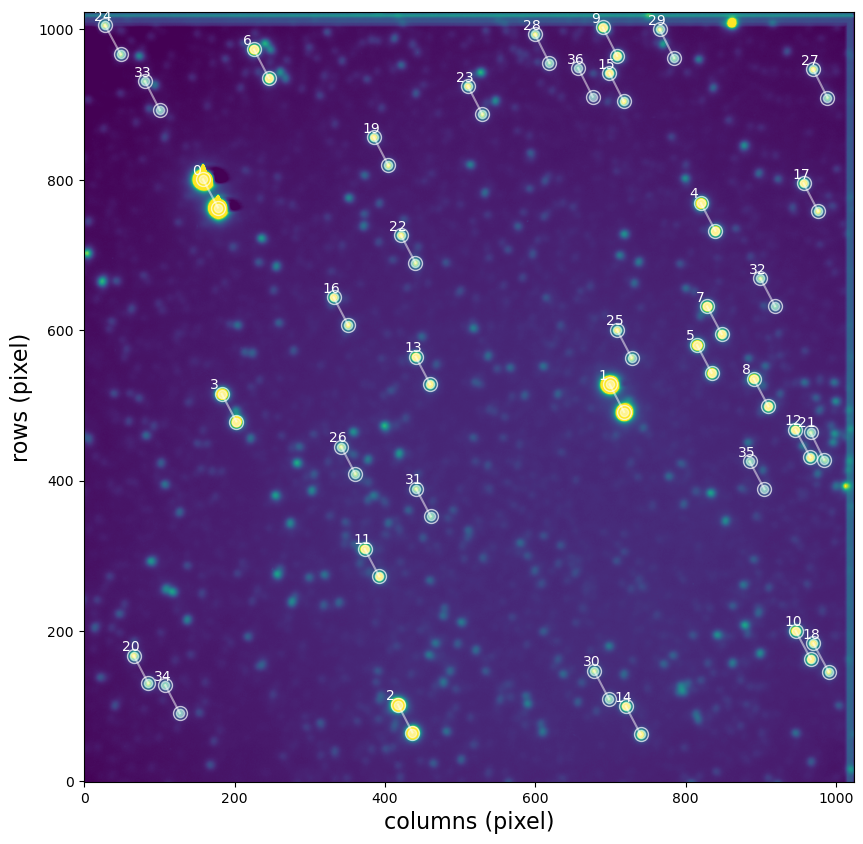

In [12]:
s4plt.plot_sci_polar_frame(polar_stack_example)

Now print one of the catalogs to see its contents

In [14]:
catalog = 'CATALOG_POL_N_AP010'
pd.DataFrame(hdul[catalog].data)

,SRCINDEX,RA,DEC,X,Y,FWHMX,FWHMY,MAG,EMAG,SKYMAG,ESKYMAG,APER,FLAG
0,0,258.181399,-24.224207,177.923108,763.025432,11.155057,11.155057,-11.957490,0.000406,-9.583033,0.001270,10,0
1,1,258.125112,-24.248660,718.024583,491.267928,10.514521,10.514521,-11.612172,0.000483,-9.677144,0.000950,10,0
2,2,258.152872,-24.289191,436.588762,64.920628,8.902475,8.902475,-10.605507,0.000888,-9.661621,0.000921,10,0
3,3,258.178066,-24.250921,202.444660,478.536338,8.972065,8.972065,-10.000463,0.001371,-9.620952,0.001038,10,0
4,4,258.113326,-24.225801,839.420680,732.211049,8.891305,8.891305,-9.812860,0.001573,-9.620414,0.001037,10,0
5,5,258.113315,-24.243527,834.397983,543.306281,8.833100,8.833100,-9.730056,0.001555,-9.657562,0.000727,10,0
6,6,258.174907,-24.207874,245.871244,935.067740,8.577665,8.577665,-9.632659,0.001782,-9.562924,0.001083,10,0
7,7,258.112082,-24.238677,847.876601,594.705732,8.910812,8.910812,-9.491675,0.001882,-9.644373,0.000793,10,0
8,8,258.105455,-24.247554,909.940702,498.637786,8.771791,8.771791,-9.464514,0.001918,-9.648304,0.000782,10,0
9,9,258.127352,-24.204172,708.867057,964.759367,8.311174,8.311174,-9.378916,0.003927,-9.599877,0.002862,10,0


Below we select the source with its index number assigned as the main target to be analyzed. Then we select other stars as comparisons for differential photometry. All indices are displayed in the image above.  

After selecting the stars we use the function `s4plt.plot_light_curve` to produce plots of the lightcurve data.

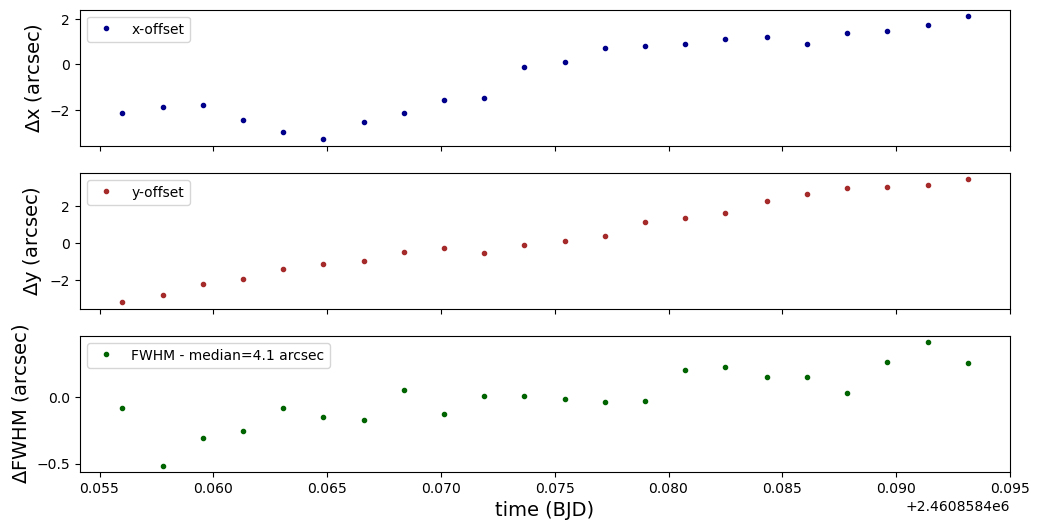

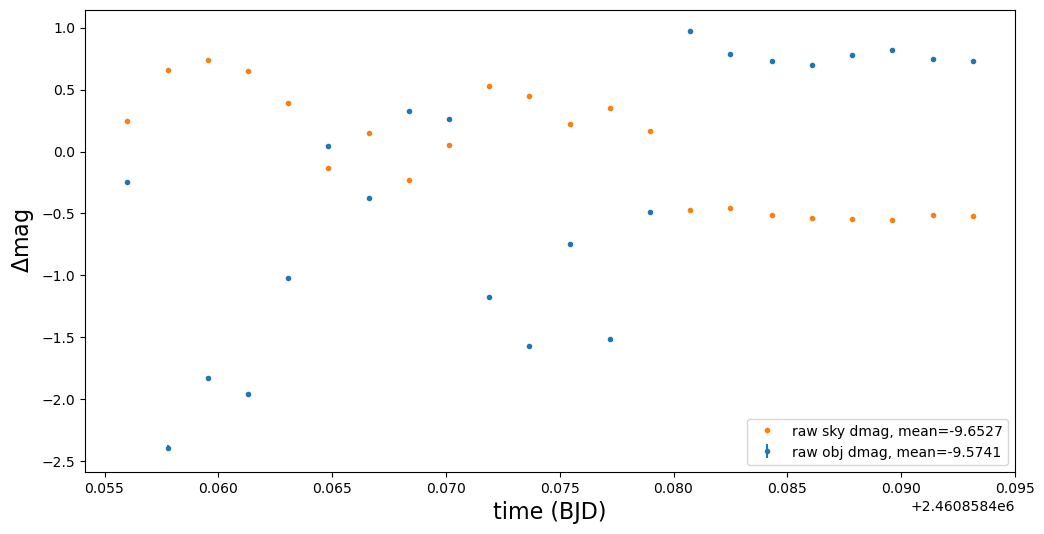

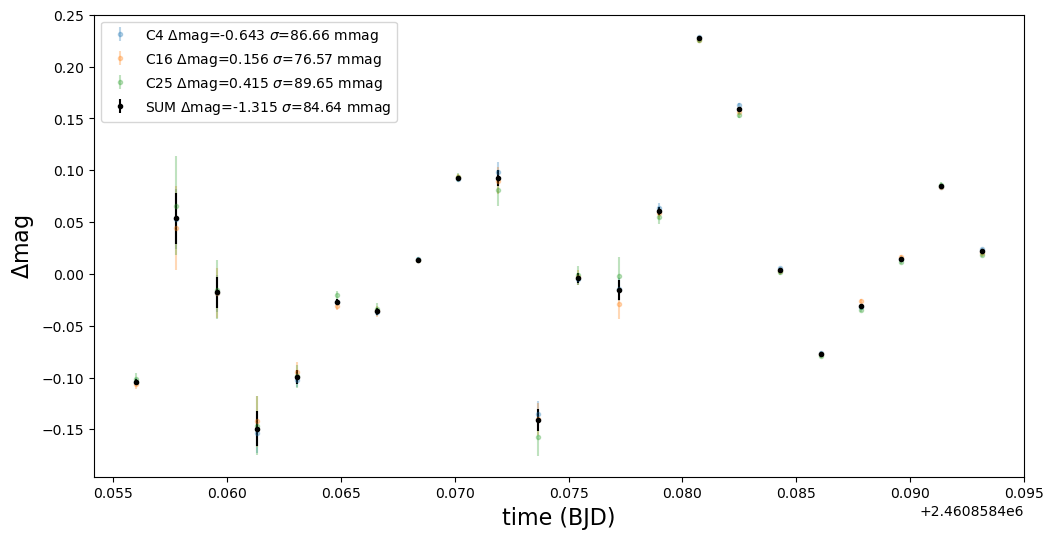

       TIME                x         ...       diffmagsum     
------------------ ----------------- ... ---------------------
2460858.4560016026 450.4969332497335 ...  -0.10412443472429533
2460858.4577726186 451.2469332497335 ...   0.05352720296999358
 2460858.459537409 451.4969332497335 ... -0.017877512591149447
2460858.4613030204 449.4969332497335 ...  -0.14925461096432446
 2460858.463069234 447.9969332497335 ...  -0.09956236493809545
 2460858.464833966 446.9969332497335 ... -0.026644949415548957
 2460858.466599219 449.2469332497335 ...  -0.03616350147950609
               ...               ... ...                   ...
2460858.4824949303 460.2469332497335 ...   0.15934994972629024
2460858.4843099266 460.4969332497335 ...  0.004011709864333746
 2460858.486078825 459.4969332497335 ...  -0.07700317543214386
 2460858.487844737 460.9969332497335 ... -0.031074977885510613
2460858.4896117486 461.2469332497335 ...  0.014452898414114124
2460858.4913803344 461.9969332497335 ...   0.0845144692

In [16]:
catalog = 'CATALOG_PHOT_AP010'
target=13
comps=[4,16,25]

lc = s4plt.plot_light_curve(phot_lightcurve_example, target=target, comps=comps, nsig=10,
                            plot_coords=True, plot_rawmags=True, plot_sum=True,
                            plot_comps=True, catalog_name=catalog)

print(lc)

Now we open a polarimetry FITS product and print its basic information

In [18]:
polar = fits.open(polar_example)
polar.info()

Filename: /media/fernando/KINGSTON/Doutorado/2025/reduced/20250701/sparc4acs2/20250701_s4c2_Gain2_1.0_Conventional_2_V2400_Oph_POLAR_L4_polar.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     159   ()      
  1  POLARIMETRY_AP005    1 BinTableHDU    258   37R x 123C   [D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D]   
  2  POLARIMETRY_AP008    1 BinTableHDU    258   37R x 123C   [D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D,

Below we print one of the catalog extensions

In [20]:
pd.DataFrame(polar["POLARIMETRY_AP010"].data)

,APERINDEX,APER,SRCINDEX,RA,DEC,X1,Y1,X2,Y2,FWHM,...,FE0019,EFE0019,FO0020,EFO0020,FE0020,EFE0020,FO0021,EFO0021,FE0021,EFE0021
0,2.0,10.0,0.0,258.181399,-24.224207,158.067916,800.655211,177.923108,763.025432,11.813273,...,87212.275102,27.774115,92773.673812,27.604988,86677.755737,27.700838,92614.582503,27.649839,86367.336763,27.559614
1,2.0,10.0,1.0,258.125112,-24.248660,698.839778,528.006562,718.024583,491.267928,9.706508,...,62297.907345,23.448424,72528.053141,25.834205,60254.844284,22.938043,72482.948134,25.973188,60305.876589,23.075093
2,2.0,10.0,2.0,258.152872,-24.289191,417.281487,102.117646,436.588762,64.920628,8.966821,...,26971.019555,18.983955,29722.039914,18.441276,23938.950134,18.063908,30932.150030,18.598589,25167.446292,18.357874
3,2.0,10.0,3.0,258.178066,-24.250921,182.987019,515.296824,202.444660,478.536338,8.899045,...,15929.128640,14.223300,17002.458070,15.400629,14108.282514,13.542912,17820.021948,15.451810,14769.920978,13.830141
4,2.0,10.0,4.0,258.113326,-24.225801,820.045722,769.017943,839.420680,732.211049,8.720721,...,11683.049480,13.623337,14340.312470,14.681110,10372.327823,13.117328,14946.453440,14.938132,10768.290823,13.309733
5,2.0,10.0,5.0,258.113315,-24.243527,815.078989,580.139676,834.397983,543.306281,8.680380,...,11547.108466,13.757752,13223.737049,13.700139,10260.780148,13.143407,13821.989888,13.988141,10754.561602,13.447737
6,2.0,10.0,6.0,258.174907,-24.207874,225.835698,973.310245,245.871244,935.067740,8.534484,...,10551.156736,12.575637,12142.492155,14.103208,9414.918988,12.588755,12726.630252,14.638411,9814.818405,12.566936
7,2.0,10.0,7.0,258.112082,-24.238677,828.463509,631.546824,847.876601,594.705732,8.655742,...,9232.758425,14.872531,10658.400721,13.495502,8133.884621,14.222344,11092.852010,13.729550,8527.306907,14.392177
8,2.0,10.0,8.0,258.105455,-24.247554,890.401499,535.516017,909.940702,498.637786,8.626958,...,8980.832018,16.305839,10384.724900,13.636209,7956.425161,16.518909,10807.641718,13.943608,8350.987050,16.214883
9,2.0,10.0,9.0,258.127352,-24.204172,689.719940,1002.528038,708.867057,964.759367,8.507246,...,8895.890136,25.235600,6511.557445,18.543177,7881.614222,25.803165,5848.016358,17.300908,8243.086987,25.284227


Then we can print all column names to check the data available in each catalog

In [22]:
pd.DataFrame(polar["POLARIMETRY_AP010"].data).columns

Index(['APERINDEX', 'APER', 'SRCINDEX', 'RA', 'DEC', 'X1', 'Y1', 'X2', 'Y2',
       'FWHM',
       ...
       'FE0019', 'EFE0019', 'FO0020', 'EFO0020', 'FE0020', 'EFE0020', 'FO0021',
       'EFO0021', 'FE0021', 'EFE0021'],
      dtype='object', length=123)

Finally, we can select the source of interest and then we get the polarimetry results using the function `get_polarimetry_results` from `sparc4.pipeline_lib` library:

2025-11-22 01:02:16,110 astropop - INFO - Normalization disabled.  [__init__]


2025-11-22 01:02:16,110 | INFO | Normalization disabled.


/home/fernando/anaconda3/lib/python3.12/site-packages/astropop/math/_deriv.py:29: RuntimeWarning: invalid value encountered in log
  return np.log(x)*np.power(x, y)
2025-11-22 01:02:16,121 root - INFO - Source index: i=13   [pipeline_lib]


2025-11-22 01:02:16,121 | INFO | Source index: i=13 


2025-11-22 01:02:16,122 root - INFO - Source RA=258.15171067049596 Dec=-24.245753443334355 mag=-13.2332+-0.0005  [pipeline_lib]


...

2025-11-22 01:02:16,251 | INFO | Substituting symbol \perp from STIXGeneral


2025-11-22 01:02:16,597 matplotlib.mathtext - INFO - Substituting symbol \perp from STIXGeneral  [_mathtext]


2025-11-22 01:02:16,597 | INFO | Substituting symbol \perp from STIXGeneral


2025-11-22 01:02:16,603 matplotlib.mathtext - INFO - Substituting symbol \perp from STIXGeneral  [_mathtext]


2025-11-22 01:02:16,603 | INFO | Substituting symbol \perp from STIXGeneral


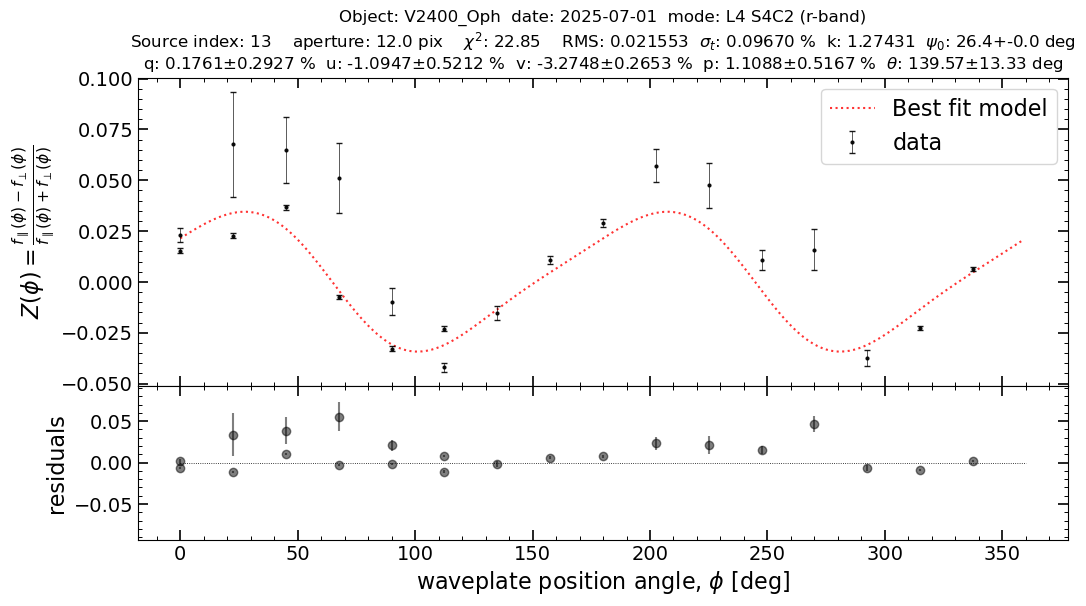

In [24]:
source_index = target

pol_results = s4pipelib.get_polarimetry_results(polar_example,
                                                source_index=source_index,
                                                min_aperture=5,
                                                max_aperture=21,
                                                plot=True,
                                                verbose=True)

Below we print all variables names for the measurements available in the polar product

In [26]:
for key in pol_results.keys():
    print(key, ":", pol_results[key])

POLAR_PRODUCT : /media/fernando/KINGSTON/Doutorado/2025/reduced/20250701/sparc4acs2/20250701_s4c2_Gain2_1.0_Conventional_2_V2400_Oph_POLAR_L4_polar.fits
SOURCE_INDEX : 13
POLARIMETRY_SUCCESS : True
APERTURE_INDEX : 4
APERTURE_RADIUS : 12.0
NEXPS : 22
MAG : -13.2332+-0.0005
RA : 258.15171067049596
DEC : -24.245753443334355
FWHM : 8.682503033517396
X1 : 440.87175918427187
Y1 : 564.7182876150492
X2 : 460.12210731519514
Y2 : 528.0427719886568
WAVEPLATE_ANGLES : [  0.   22.5  45.   67.5  90.  112.5 135.  157.5 180.  202.5 225.  247.5
 270.  292.5 315.  337.5   0.   22.5  45.   67.5  90.  112.5]
ZI : [0.023+-0.003, 0.07+-0.03, 0.06+-0.02, 0.05+-0.02, -0.010+-0.007,
 -0.042+-0.002, -0.015+-0.004, 0.011+-0.002, 0.029+-0.002, 0.057+-0.008,
 0.05+-0.01, 0.011+-0.005, 0.02+-0.01, -0.037+-0.004, -0.023+-0.001,
 0.006+-0.001, 0.015+-0.001, 0.023+-0.001, 0.037+-0.001, -0.007+-0.001,
 -0.033+-0.001, -0.023+-0.001]
FO : [3620+-10, 520+-20, 870+-20, 770+-20, 1720+-10, 4430+-10, 3090+-10,
 6170+-10, 579

And below we show a simple example how to get one of these measurements out. For instance, we're getting the total polarization and the polarization angle. 

In [28]:
p = pol_results["P"]*100
pa = pol_results["THETA"]
print("Polarization: {} %  Angle of polarization: {} deg".format(p,pa) )

Polarization: 1.1+-0.5 %  Angle of polarization: 140+-10 deg deg


Finally, we show below an example of a polarimetric time series product. 

In [30]:
polar_ts = fits.open(polar_time_series_example)
pd.DataFrame(polar_ts[1].data)

ValueError: Big-endian buffer not supported on little-endian compiler

ValueError: Big-endian buffer not supported on little-endian compiler

In [31]:
pd.DataFrame(polar_ts[1].data).columns

Index(['TIME', 'SRCINDEX', 'RA', 'DEC', 'X1', 'Y1', 'X2', 'Y2', 'FWHM', 'MAG',
       'EMAG', 'Q', 'EQ', 'U', 'EU', 'V', 'EV', 'P', 'EP', 'THETA', 'ETHETA',
       'K', 'EK', 'ZERO', 'EZERO', 'NOBS', 'NPAR', 'CHI2', 'RMS', 'TSIGMA'],
      dtype='object')

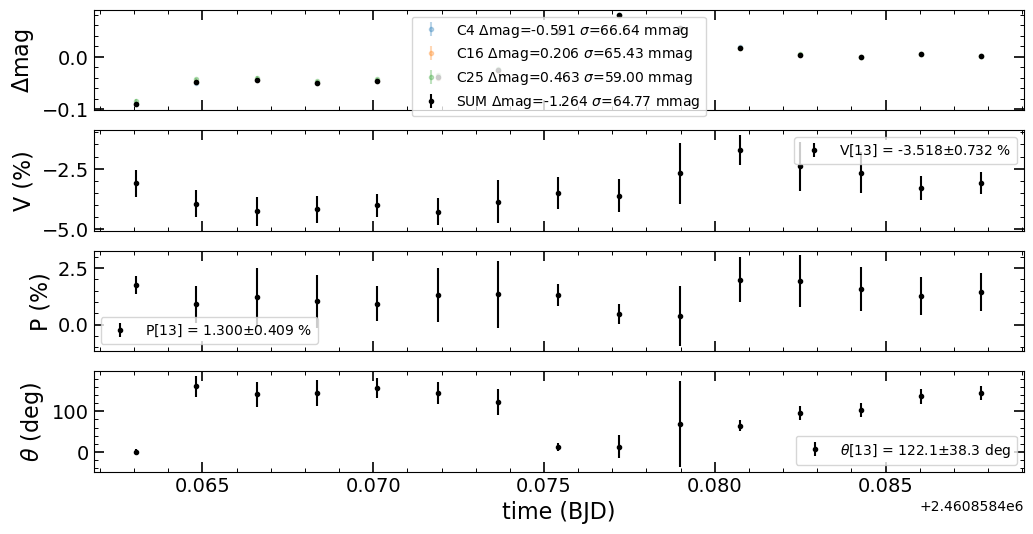

diffmag_C00000,diffmag_err_C00000,diffmag_C00001,diffmag_err_C00001,diffmag_C00002,diffmag_err_C00002,TIME,x1,y1,x2,y2,fwhm,mag,mag_err,magsum,magsum_err,diffmagsum,polarization_1,polarization_1_err,polarization_2,polarization_2_err
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
-0.09068398596447125,0.0017605060351166978,-0.09034282037024965,0.0023120603588733506,-0.08383880219004958,0.002761263650462299,2460858.463052296,440.87175918427187,564.7182876150492,460.12210731519514,528.0427719886568,8.393919373445513,-11.366862408315331,0.0015138896864587885,-12.720106093591736,0.0030321602203414967,-0.08920370098345742,0.017521420451603775,0.004148619061633963,0.7371388882118246,6.77174008183058
-0.04969437408809263,0.0016142040529283296,-0.04855098766068622,0.0021398375685463358,-0.043158528268202545,0.002575551785715197,2460858.464820309,441.62175918427187,565.9682876150492,460.87210731519514,529.2927719886568,8.379696943108243,-11.470579427172575,0.0013740978249732975,-12.782689064740664,0.0028554495350757367,-0.04806965327514057,0.009026475618849271,0.008192527803539705,161.66759102908986,25.95767219400143
-0.04494490128221429,0.0015416235357022805,-0.04413072038056676,0.002038509941617455,-0.039796727901988405,0.002464064441939943,2460858.4665853307,441.87175918427187,567.7182876150492,461.12210731519514,531.0427719886568,8.471452635859631,-11.517077114864787,0.0013106909658740027,-12.824804063837544,0.00272947010569195,-0.04368696467980904,0.012154347511372746,0.013064812771306424,142.10090256081673,30.74238620458551
-0.05053492811246585,0.0014970365979152607,-0.04995955913162575,0.0019696935613569572,-0.04662068386273788,0.002384523189986919,2460858.4683512663,439.87175918427187,568.4682876150492,459.12210731519514,531.7927719886568,8.508817542334409,-11.526827466842647,0.0012748184849114457,-12.84045688838777,0.002632731592152607,-0.04958943725217502,0.010240029752198,0.011590206864179447,145.37959698338304,32.37099152415849
-0.04639421713024561,0.0013882960589058507,-0.045995672955530864,0.0018152755056993466,-0.042386053872521146,0.002212214998255436,2460858.4701183075,438.37175918427187,570.2182876150492,457.62210731519514,533.5427719886568,8.562579353164184,-11.591361465546372,0.0011821582614387472,-12.900876737926076,0.0024339251923607245,-0.04547528808675594,0.009305740543826189,0.0077876297942223085,157.86598240351168,23.93428132514653
-0.03949553910687165,0.0014163326402182532,-0.040362125903754986,0.0018562839830776434,-0.03515778936842473,0.002266406234876087,2460858.4718836467,437.37175918427187,570.9682876150492,456.62210731519514,534.2927719886568,8.583086544563727,-11.564396058522966,0.0012037912055012313,-12.867272501767049,0.0024982085172653395,-0.038836458951134745,0.012998620839335766,0.011835991026902406,144.91586501803445,26.04194303021972
-0.025584996402990612,0.0015383759877509,-0.026214221471954957,0.0020268407747345164,-0.023451209273456897,0.002469008874810746,2460858.4736491134,439.62175918427187,571.4682876150492,458.87210731519514,534.7927719886568,8.634962629713414,-11.484022176588297,0.001304592190919018,-12.773374954239838,0.002732179839594851,-0.0253127933585926,0.01339241467929095,0.01482296294251093,122.11956413758543,31.65498905969193
0.047760137847197015,0.0011933581541156255,0.04659757705490897,0.0015896157406616565,0.04894323912381893,0.0019742851067364405,2460858.475415987,440.87175918427187,572.9682876150492,460.12210731519514,536.2927719886568,8.693508951144128,-11.792880293113512,0.000989873903313865,-13.009219270373155,0.0022156787980773286,0.04770100703330549,0.013138306398796182,0.00481817772592813,12.151377126139312,10.488405337705524
0.08013570487507593,0.00110183411232629,0.07753279512591504,0.0014743920058739456,0.0791059305860049,0.0018442790935620438,2460858.477181465,442.62175918427187,573.4682876150492,461.87210731519514,536.7927719886568,8.70287647671

In [32]:
s4plt.plot_polar_time_series(polar_time_series_example, 
                             target=target, 
                             comps=comps, 
                             plot_total_polarization=True, 
                             plot_polarization_angle=True)